# <p style="text-align:center">Automobiles Model Development

In this section, several models will be developed that will predict the price of car using the variables or features. This is just an estimate but should give an objective idea of how much a car should cost

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [4]:
file_path= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"

In [5]:
df = pd.read_csv(file_path)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


## 1. Linear Regression and Multiple Linear Regression

#### Simple Linear Regression
Simple Linear Regression method will be used and it helps to understand the relationship between two variables:

+ The predictor/independent variable (X)
+ The response/dependent variable (that we want to predict)(Y)

The result of Linear Regression is a linear function that predicts the response (dependent) variable as a function of the predictor (independent) variable.



$$
 Y: Response \ Variable\\\\\\
 X: Predictor \ Variables
$$


 <b>Linear Function</b>
$$
Yhat = a + b  X
$$


+ a refers to the intercept of the regression line, in other words: the value of Y when X is 0
+ b refers to the slope of the regression line, in other words: the value with which Y changes when X increases by 1 unit

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
# Creating the linear regression object

lm = LinearRegression()
lm

LinearRegression()

#### Predicting car price using predictor variables

In [14]:
# using highway-mpg

X = df[['highway-mpg']]
Y = df['price']

In [15]:
lm.fit(X,Y)

LinearRegression()

In [16]:
# price prediction

Yhat=lm.predict(X)
print('The output of the first four predicted value is: ', Yhat[0:4])

The output of the first four predicted value is:  [16236.50464347 16236.50464347 17058.23802179 13771.3045085 ]


In [17]:
# the value of the intercept (a)

lm.intercept_

38423.305858157386

In [18]:
# the value of the slope (b)

lm.coef_

array([-821.73337832])

In [19]:
# Plugging in the actual values

Yhat = 38423.31 - 821.73 * X

In [20]:
Yhat.head(20)

,highway-mpg
0,16236.60
1,16236.60
2,17058.33
3,13771.41
4,20345.25
5,17880.06
6,17880.06
7,17880.06
8,21988.71
9,14593.14


In [21]:
a = df[['engine-size']]
b = df['price']

In [22]:
# using engine-size variable

lm1 = LinearRegression()
lm1

LinearRegression()

In [23]:
lm1.fit(a, b)
lm1

LinearRegression()

In [24]:
# the value of the slope

lm1.coef_

array([166.86001569])

In [25]:
# the value of the intercept

lm1.intercept_

-7963.338906281049

In [26]:
Yhat1 =lm1.predict(a)
Yhat1[0:5]

array([13728.4631336 , 13728.4631336 , 17399.38347881, 10224.40280408,
       14729.62322775])

In [27]:
# Price prediction

Price=-7963.34 + 166.86*df[['engine-size']]
Price

,engine-size
0,13728.46
1,13728.46
2,17399.38
3,10224.40
4,14729.62
...,...
196,15563.92
197,15563.92
198,20903.44
199,16231.36


#### Multiple Linear Regression
This method is used to explain the relationship between one continuous response (dependent) variable and <b>two or more</b> predictor (independent) variables

Prediction of car price wil be done making use of four variables

$$
Y: Response \ Variable\\\\\\
X_1 :Predictor\ Variable \ 1\\
X_2: Predictor\ Variable \ 2\\
X_3: Predictor\ Variable \ 3\\
X_4: Predictor\ Variable \ 4\\
$$


$$
a: intercept\\\\\\
b_1 :coefficients \ of\ Variable \ 1\\
b_2: coefficients \ of\ Variable \ 2\\
b_3: coefficients \ of\ Variable \ 3\\
b_4: coefficients \ of\ Variable \ 4\\
$$


The equation is given by:

    
$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$


From the previous section, four good predictors of price could be:

+ Horsepower
+ Curb-weight
+ Engine-size
+ Highway-mpg

A model is developed using these variables as the predictor variables.

In [33]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

In [34]:
lm.fit(Z, df['price'])

LinearRegression()

In [35]:
# the value of the intercept (a)

lm.intercept_

-15806.624626329198

In [36]:
# the values of the coefficients (b1, b2, b3, b4)

lm.coef_

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$


In [38]:
Yhat2 = -15806.624626329198 + 53.49574423 * df['horsepower'] + 4.70770099 * df['curb-weight'] + 81.53026382 * df['engine-size'] + 36.05748882 * df['highway-mpg']
print(Yhat2)

0      13699.111600
1      13699.111600
2      19051.654690
3      10620.361920
4      15521.314189
           ...     
196    16694.400424
197    19503.679188
198    20475.458366
199    17804.038799
200    17104.075066
Length: 201, dtype: float64


## 2. Model Evaluation Using Visualization</h2>


In [40]:
import seaborn as sns
%matplotlib inline 

### Regression Plot

This plot will show a combination of a scattered data points (a scatterplot), as well as the fitted linear regression line going through the data. This will give a reasonable estimate of the relationship between the two variables, the strength of the correlation, as well as the direction (positive or negative correlation).

(0.0, 48172.1665577077)

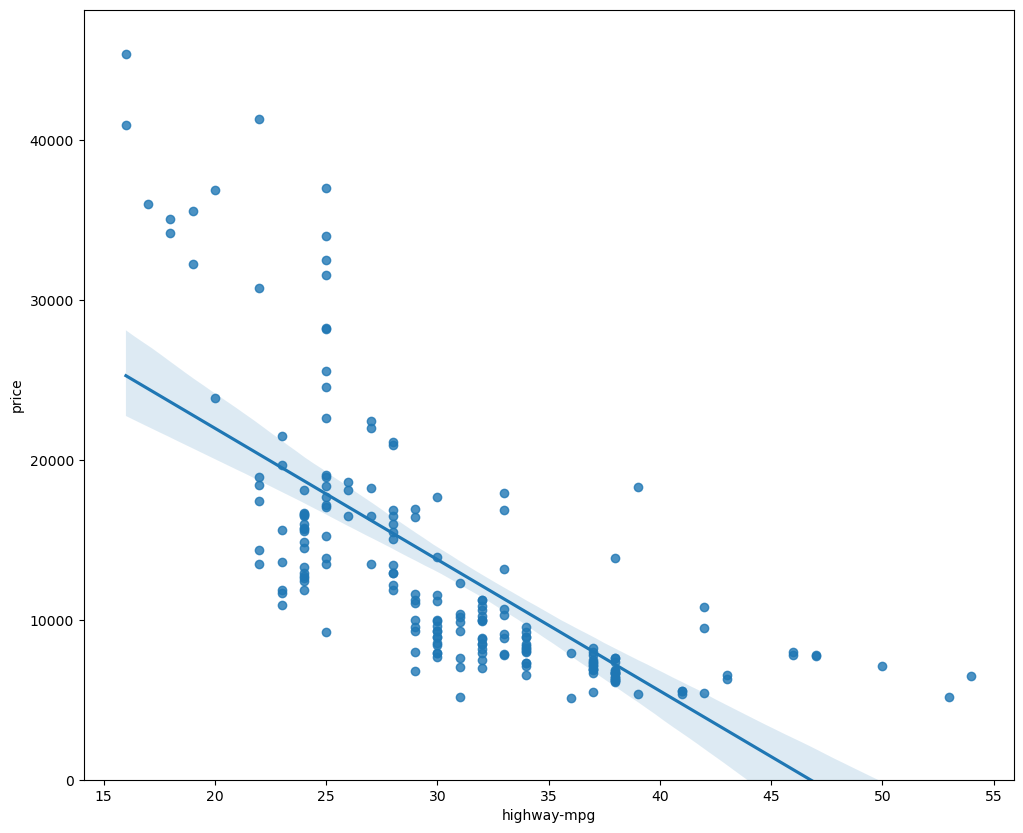

In [43]:
# highway-mpg as potential predictor variable of price

width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)

This plot shows that price is negatively correlated to highway-mpg since the regression slope is negative.

(0.0, 47414.1)

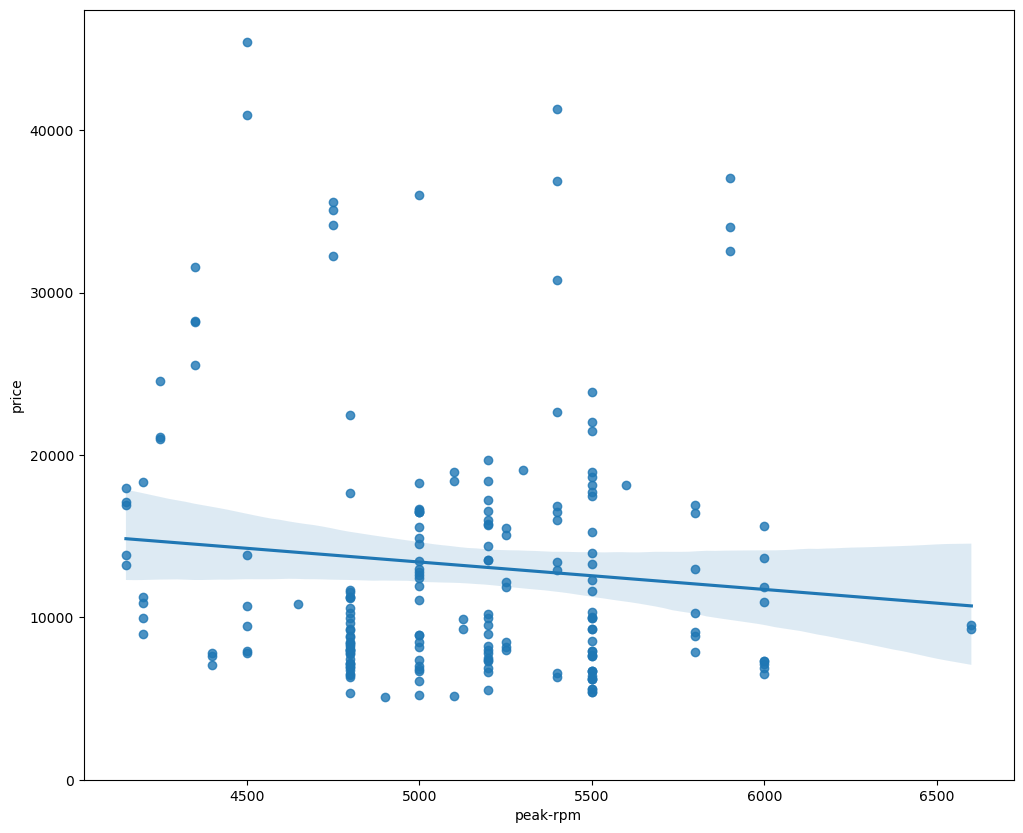

In [45]:
# the regression plot of "peak-rpm"

plt.figure(figsize=(width, height))
sns.regplot(x="peak-rpm", y="price", data=df)
plt.ylim(0,)

Comparing the regression plot of "peak-rpm" and "highway-mpg", the points for "highway-mpg" are much closer to the generated line and, on average, decrease. The points for "peak-rpm" have more spread around the predicted line and it is much harder to determine if the points are decreasing or increasing as the "peak-rpm" increases.


In [47]:
# correlation btw "peak-rpm" and "highway-mpg"

df[["peak-rpm","highway-mpg","price"]].corr()

,peak-rpm,highway-mpg,price
peak-rpm,1.000000,-0.058598,-0.101616
highway-mpg,-0.058598,1.000000,-0.704692
price,-0.101616,-0.704692,1.000000


The variable "highway-mpg" has a stronger correlation with "price", it is approximate -0.704692 compared to "peak-rpm" which is approximate -0.101616

### Residual Plot
The best way to visualize the variance of the data is to use a residual plot. The difference between the observed value (y) and the predicted value (Yhat) is called the residual (e). When we look at a regression plot, the residual is the distance from the data point to the fitted regression line.

A residual plot is a graph that shows the residuals on the vertical y-axis and the independent variable on the horizontal x-axis. 

If the points in a residual plot are randomly spread out around the x-axis, then a linear model is appropriate for the data. Randomly spread out residuals means that the variance is constant, and thus the linear model is a good fit for this data.

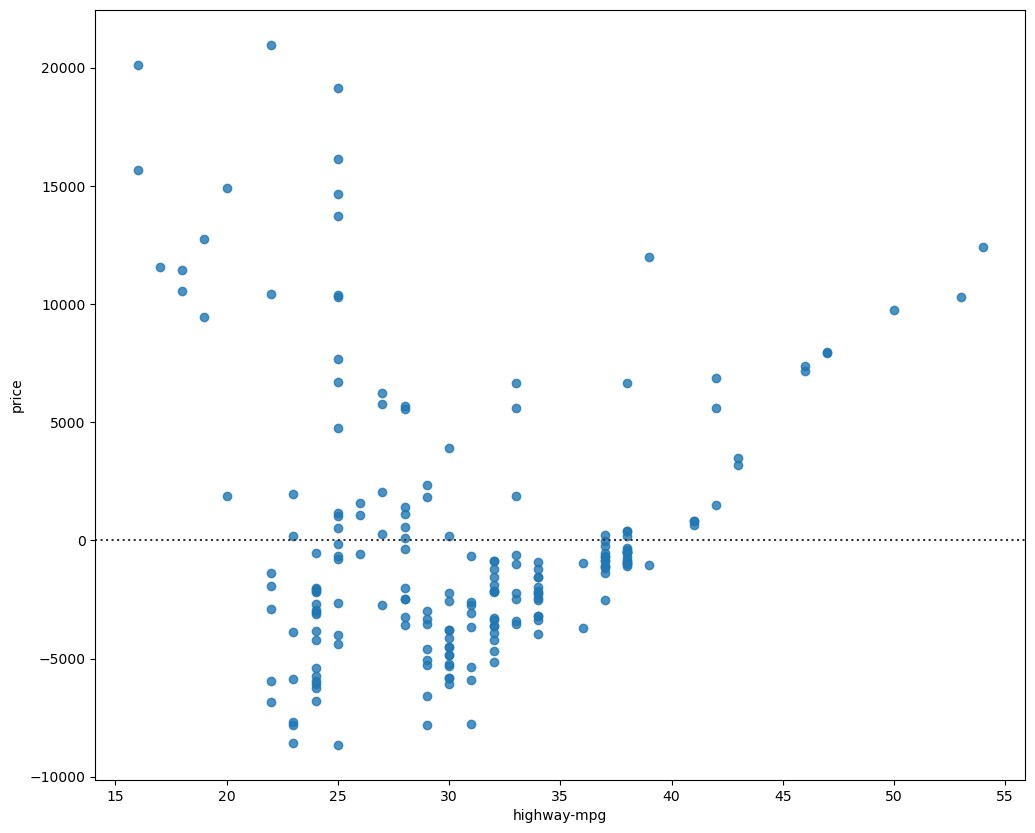

In [51]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

From this residual plot that the residuals are not randomly spread around the x-axis, leading us to believe that maybe a non-linear model is more appropriate for this data

#### Distribution Plot For Multiple Linear Regression

The distribution of the fitted values that result from a model is compared to the distribution of the actual values to confirm if they are fitted or overlapped.

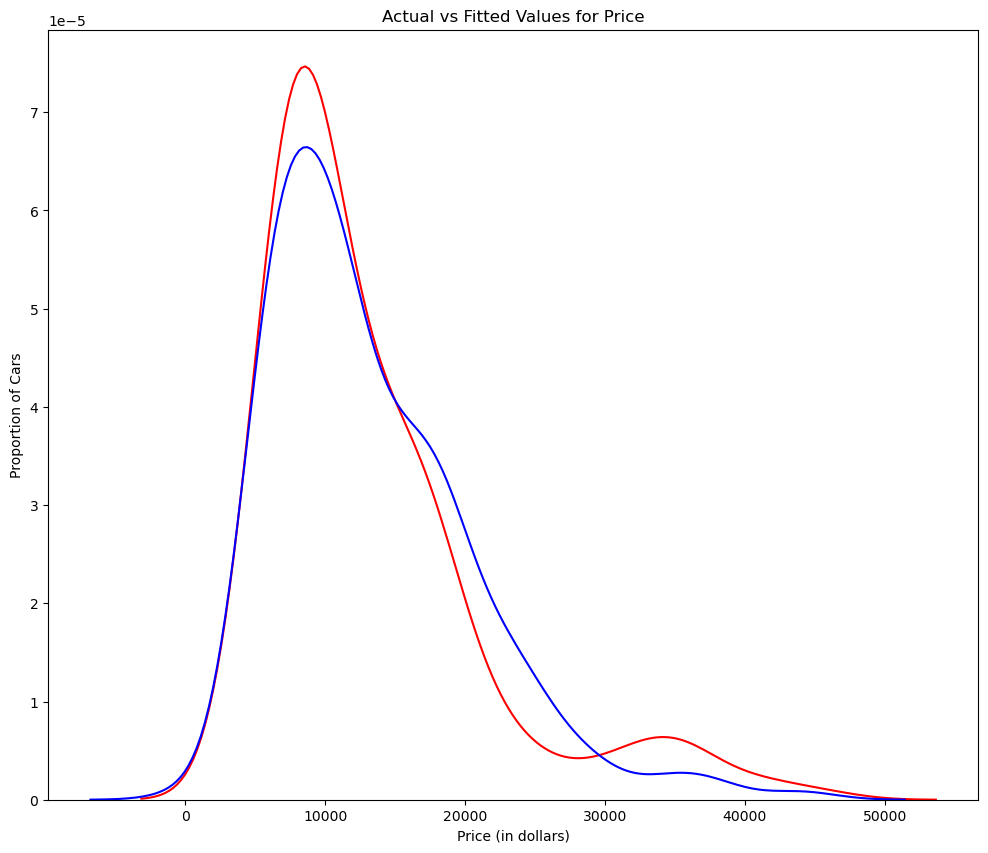

In [55]:
plt.figure(figsize=(width, height))


ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Yhat2, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

The fitted values are reasonably close to the actual values since the two distributions overlap a bit. However, there is definitely some room for improvement.

#### 3. Polynomial Regression and Pipelines

Polynomial regression is a particular case of the general linear regression model or multiple linear regression models.

Non-linear relationships is gotten by squaring or setting higher-order terms of the predictor variables.

There are different orders of polynomial regression:

<center><b>Quadratic - 2nd Order</b></center>
$$
Yhat = a + b_1 X +b_2 X^2 
$$


<center><b>Cubic - 3rd Order</b></center>
$$
Yhat = a + b_1 X +b_2 X^2 +b_3 X^3\\\\\\
$$


<center><b>Higher-Order</b>:</center>
$$
Y = a + b_1 X +b_2 X^2 +b_3 X^3 ....\\
$$


A linear model did not provide the best fit while using "highway-mpg" as the predictor variable, a polynomial model is then fitted to the data instead.

In [61]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

In [62]:
x = df['highway-mpg']
y = df['price']

In [63]:
# using a polynomial of the 3rd order (cubic) 
f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


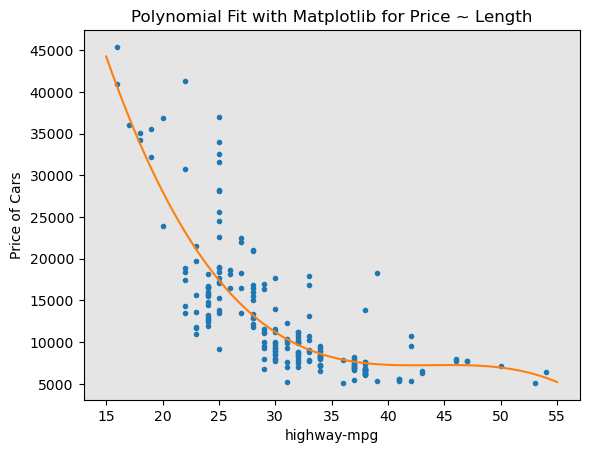

In [64]:
PlotPolly(p, x, y, 'highway-mpg')

In [65]:
np.polyfit(x, y, 3)

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

Polynomial model performs better than the linear model. This is because the generated polynomial function "hits" more of the data points.

            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08


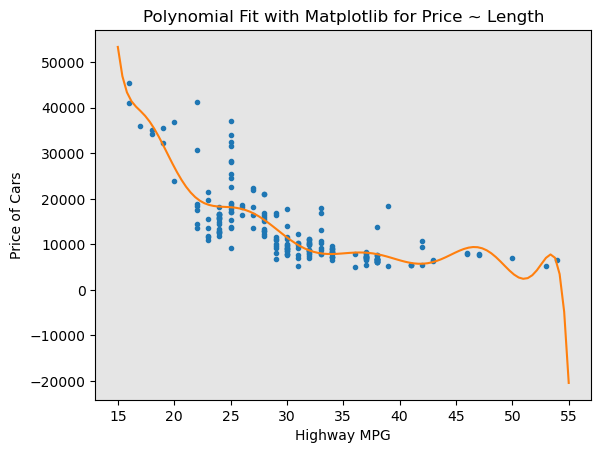

In [67]:
# Creating 11 order polynomial model with the variables x and y 

f1 = np.polyfit(x, y, 11)
p1 = np.poly1d(f1)
print(p1)
PlotPolly(p1,x,y, 'Highway MPG')

#### Analytical Expression For Multivariate Polynomial

The analytical expression for Multivariate Polynomial function gets complicated. For example, the expression for a second-order (degree=2) polynomial with two variables is given by:

$$
Yhat = a + b_1 X_1 +b_2 X_2 +b_3 X_1 X_2+b_4 X_1^2+b_5 X_2^2
$$


At first, a polynomial transform is perform on the multiple features.

In [72]:
from sklearn.preprocessing import PolynomialFeatures

In [73]:
pr=PolynomialFeatures(degree=2)
pr

PolynomialFeatures()

In [74]:
Z_pr=pr.fit_transform(Z)

In [75]:
Z.shape

(201, 4)

In the original data, there are 201 samples and 4 features.

In [77]:
Z_pr.shape

(201, 15)

After the transformation, there are 201 samples and 15 features.

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

A pipeline is creatyed by creating a list of tuples including the name of the model or estimator and its corresponding constructor.

In [81]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

In [82]:
# the input listed as an argument to the pipeline constructor
pipe=Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

First, the data type Z is converted to type float to avoid conversion warnings that may appear as a result of StandardScaler taking float inputs.

The data is then normalize, a transform is performed and fit the model simultaneously

In [84]:
Z = Z.astype(float)
pipe.fit(Z,y)

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [85]:
ypipe=pipe.predict(Z)
ypipe[0:4]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555])

Creating a pipeline that standardizes the data, then produce a prediction using a linear regression model using the features Z and target y.

In [87]:
Input=[('scale',StandardScaler()),('model',LinearRegression())]

pipe=Pipeline(Input)

pipe.fit(Z,y)

ypipe=pipe.predict(Z)
ypipe[0:10]

array([13699.11161184, 13699.11161184, 19051.65470233, 10620.36193015,
       15521.31420211, 13869.66673213, 15456.16196732, 15974.00907672,
       17612.35917161, 10722.32509097])

### 4. Measures for In-Sample Evaluation

When evaluating m aodel, a quantitative measure is required to determine how accurate the model is.

Two very important measures that are often used in Statistics to determine the accuracy of a model are:

+ **R^2 / R-squared**
+ **Mean Squared Error (MSE)**

**R-squared**

R squared, also known as the coefficient of determination, is a measure to indicate how close the data is to the fitted regression line.

The value of the R-squared is the percentage of variation of the response variable (y) that is explained by a linear model.

**Mean Squared Error (MSE)**

The Mean Squared Error measures the average of the squares of errors. That is, the difference between actual value (y) and the estimated value (ŷ).

#### Model 1: Simple Linear Regression

Calculating the R^2:

In [92]:
#highway_mpg_fit
lm.fit(X, Y)
# Find the R^2
print('The R-square is: ', lm.score(X, Y))

The R-square is:  0.4965911884339175


Approximately 49.659% of the variation of the price is explained by simple linear model "horsepower_fit" earlier.

Calculating the MSE:

The predicted value using simple linear regression "yhat" from the predicted method, where X is the input variable:

In [95]:
Yhat=lm.predict(X)
print('The output of the first four predicted value is: ', Yhat[0:4])

The output of the first four predicted value is:  [16236.50464347 16236.50464347 17058.23802179 13771.3045085 ]


In [96]:
from sklearn.metrics import mean_squared_error

Comparing the predicted results with the actual results:

In [98]:
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The mean square error of price and predicted value is:  31635042.944639895


#### Model 2: Multiple Linear Regression

Calculating the R^2:

In [101]:
lm.fit(Z, df['price'])
print('The R-square is: ', lm.score(Z, df['price']))

The R-square is:  0.8093562806577457


Approximately 80.896 % of the variation of price is explained by this multiple linear regression "multi_fit".

Calculating the MSE:

In [104]:
Y_predict_multifit = lm.predict(Z)

Comparing the predicted results with the actual results:

In [106]:
print('The mean square error of price and predicted value using multifit is: ', \
      mean_squared_error(df['price'], Y_predict_multifit))

The mean square error of price and predicted value using multifit is:  11980366.87072649


#### Model 3: Polynomial Fit

Calculating the R^2:

Importing the **r2_score** functiom from the module **metrics** as this is a different function.

In [110]:
from sklearn.metrics import r2_score

In [111]:
r_squared = r2_score(y, p(x))
print('The R-square value is: ', r_squared)

The R-square value is:  0.6741946663906513


Approximately 67.419 % of the variation of price is explained by this polynomial fit.

Calculating the MSE:

In [114]:
mean_squared_error(df['price'], p(x))

20474146.42636125

### 5. Decision

Different models has been visualized, the R-squared and MSE values for the fits were generated, how is a good model fit determined?

What is a good R-squared value?
When comparing models, **the model with the higher R-squared value** is a better fit for the data.

What is a good MSE?
When comparing models, **the model with the smallest MSE value** is a better fit for the data.

**The values for the different models.**
Simple Linear Regression: Using Highway-mpg as a Predictor Variable of Price.

+ R-squared: 0.49659118843391759
+ MSE: 3.16 x10^7

Multiple Linear Regression: Using Horsepower, Curb-weight, Engine-size, and Highway-mpg as Predictor Variables of Price.

* R-squared: 0.80896354913783497
* MSE: 1.2 x10^7

Polynomial Fit: Using Highway-mpg as a Predictor Variable of Price.

+ R-squared: 0.6741946663906514
+ MSE: 2.05 x 10^7

Usually, the more variables, the better the model is at predicting, but this is not always true. Sometimes there may not be enough data, numerical problems, or many of the variables may not be useful and even act as noise. As a result, there is a need to always check the MSE and R^2.


Comparing these three models, the MLR model is the best model to be able to predict price from the dataset. This result makes sense since there are 27 variables in total and more than one of those variables are potential predictors of the final car price.